## 5. Segmentation via TensorFlow U-Net
Next, we segment the pits using a pre-trained U-Net model. 

*Note: The model expects a custom loss function (`dice_focal_loss`) to be passed during loading, even if we only run inference. We provide a dummy function to satisfy the keras loader requirements.

In [1]:
import sys
import platform

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Architecture:", platform.machine())

Python executable: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis/venv-ml/bin/python
Python version: 3.10.20 (main, Mar  3 2026, 00:49:35) [Clang 17.0.0 (clang-1700.6.4.2)]
Architecture: arm64


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import skimage

print("numpy:", np.__version__)
print("tensorflow:", tf.__version__)
print("skimage:", skimage.__version__)
print("devices:", tf.config.list_physical_devices())
print("gpus:", tf.config.list_physical_devices("GPU"))

numpy: 1.26.4
tensorflow: 2.16.2
skimage: 0.25.2
devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
gpus: []


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import gwyfile

afm_data = np.load(
    "Data-Conversion/NPY/SPM_2nm_QD_AFMs_AIX6461_along_the_round_edge_1um_200pN_10gain_2um_zrange.0_00000/"
    "channel_00___0_data.npy")

In [5]:
import copy
from scipy.ndimage import median_filter

# topo_corrected = afm_data.copy()
topo_corrected = np.copy(afm_data)

# 1. Row alignment (subtract median of each row)
topo_corrected -= np.median(topo_corrected, axis=1)[:, np.newaxis]

# 2. Scar removal using a median filter (simple approach)
topo_corrected = median_filter(topo_corrected, size=(1, 5))

# 3. 2D plane fit (flatten plane)
X, Y = np.meshgrid(np.arange(topo_corrected.shape[1]), np.arange(topo_corrected.shape[0]))
A = np.column_stack((X.ravel(), Y.ravel(), np.ones(X.size)))
C, _, _, _ = np.linalg.lstsq(A, topo_corrected.ravel(), rcond=None)
plane = (A @ C).reshape(topo_corrected.shape)
topo_corrected -= plane

# topo_corrected is now ready for segmentation
afm_data = topo_corrected

U-Net loaded successfully.
Expected input shape: (None, 128, 128, 1)


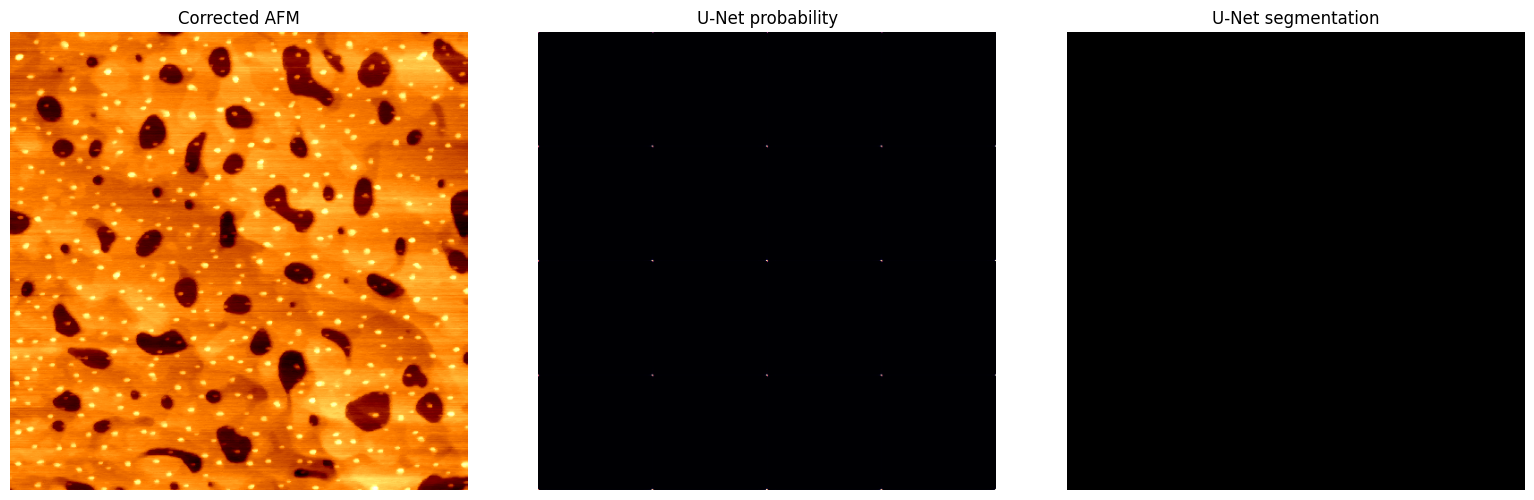

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras


unet_path = "Ground-Truth/qd_unet_fold1.keras"

unet_model = keras.models.load_model(unet_path, compile=False)
print("U-Net loaded successfully.")
print("Expected input shape:", unet_model.input_shape)


def predict_unet_tiled(model, image, patch_size=128, threshold=0.5):
    image = np.asarray(image, dtype=np.float32)

    original_rows, original_columns = image.shape

    padded_rows = int(np.ceil(original_rows / patch_size) * patch_size)
    padded_columns = int(np.ceil(original_columns / patch_size) * patch_size)

    padded_image = np.pad(
        image,
        ((0, padded_rows - original_rows), (0, padded_columns - original_columns)),
        mode="reflect",
    )

    prediction = np.zeros_like(padded_image, dtype=np.float32)

    for row in range(0, padded_rows, patch_size):
        for column in range(0, padded_columns, patch_size):
            patch = padded_image[row:row + patch_size, column:column + patch_size]
            patch_tensor = patch[np.newaxis, ..., np.newaxis]
            patch_prediction = model.predict(patch_tensor, verbose=0)[0, ..., 0]
            prediction[row:row + patch_size, column:column + patch_size] = patch_prediction

    prediction = prediction[:original_rows, :original_columns]
    binary_mask = prediction > threshold

    return prediction, binary_mask


prediction_unet, binary_mask_unet = predict_unet_tiled(
    model=unet_model,
    image=afm_data,
    patch_size=128,
    threshold=0.5,
)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(afm_data, cmap="afmhot")
axes[0].set_title("Corrected AFM")

axes[1].imshow(prediction_unet, cmap="magma")
axes[1].set_title("U-Net probability")

axes[2].imshow(binary_mask_unet, cmap="gray")
axes[2].set_title("U-Net segmentation")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Making decision boundaries for the dots, dots within defects and any interesting artefacts. 

Making a separate cost function for all of these? 